In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
from collections import *
from zipfile import ZipFile
import datetime 
from dateutil import tz
import mplcursors

In [3]:
taxi = pd.read_csv('./train.csv')
taxi.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0


In [4]:
taxi_new = taxi.sample(n=100000,random_state=5)

In [5]:
taxi_new.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
311497,2012-11-02 09:11:00.000000136,16.0,2012-11-02 09:11:00 UTC,-74.014600,40.716837,-73.979737,40.751940,5.0
28743711,2009-08-13 15:21:45.0000005,4.5,2009-08-13 15:21:45 UTC,-73.962769,40.758413,-73.953383,40.768410,1.0
42622178,2013-01-18 01:12:00.00000088,19.0,2013-01-18 01:12:00 UTC,-73.972272,40.758425,-73.906782,40.727670,5.0
14444931,2014-10-05 00:54:00.00000036,8.5,2014-10-05 00:54:00 UTC,-73.954132,40.707030,-73.941623,40.719857,5.0
24320687,2015-02-23 23:18:43.0000001,22.0,2015-02-23 23:18:43 UTC,-73.976227,40.754017,-73.963631,40.718544,1.0


## Exploratory Analysis - 3 Main Questions
   1. Does the time of day effect the fair
   2. How does the fare change based on location
   3. How much does the fare increase per distance increment increase

In [6]:
taxi_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 311497 to 30749394
Data columns (total 8 columns):
key                  100000 non-null object
fare_amount          100000 non-null float64
pickup_datetime      100000 non-null object
pickup_longitude     100000 non-null float64
pickup_latitude      100000 non-null float64
dropoff_longitude    99999 non-null float64
dropoff_latitude     99999 non-null float64
passenger_count      100000 non-null float64
dtypes: float64(6), object(2)
memory usage: 6.9+ MB


This confirms that the data is preprocessed well and doesn't have any null objects in the dataset. It also indicates the types of variables we have which could be useful for converting between columns. 

### 1. Time of Day

In [7]:
taxi_new["pickup_datetime"] = pd.to_datetime(taxi_new['pickup_datetime'],infer_datetime_format=True)

In [8]:
taxi_new["day_of_week"] = taxi_new.pickup_datetime.dt.dayofweek
taxi_new["month"] = taxi_new.pickup_datetime.dt.month
taxi_new["month_name"] = taxi_new.pickup_datetime.dt.month_name()
taxi_new["hour"] = taxi_new.pickup_datetime.dt.hour
taxi_new["dayname"] = taxi_new.pickup_datetime.dt.day_name()

In [9]:
taxi_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 311497 to 30749394
Data columns (total 13 columns):
key                  100000 non-null object
fare_amount          100000 non-null float64
pickup_datetime      100000 non-null datetime64[ns]
pickup_longitude     100000 non-null float64
pickup_latitude      100000 non-null float64
dropoff_longitude    99999 non-null float64
dropoff_latitude     99999 non-null float64
passenger_count      100000 non-null float64
day_of_week          100000 non-null int64
month                100000 non-null int64
month_name           100000 non-null object
hour                 100000 non-null int64
dayname              100000 non-null object
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 10.7+ MB


Text(0.5, 1.0, 'Number of trips on each day of the week')

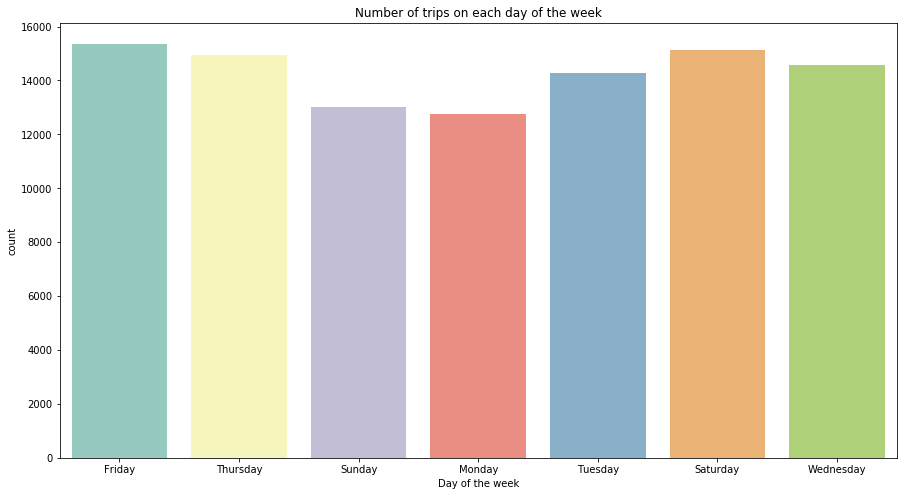

In [10]:
plt.figure(figsize=(15,8))
sns.countplot(x='dayname',data=taxi_new, palette="Set3")
plt.xlabel('Day of the week')
plt.title('Number of trips on each day of the week')

In [11]:
useful_columns = ['fare_amount', 'dayname'] #list the columns I need
taxi_new[useful_columns].to_csv('dayfare.csv', index=False)

In [12]:
dayfare = pd.read_csv('./dayfare.csv')
dayfare.head()

,fare_amount,dayname
0,16.0,Friday
1,4.5,Thursday
2,19.0,Friday
3,8.5,Sunday
4,22.0,Monday


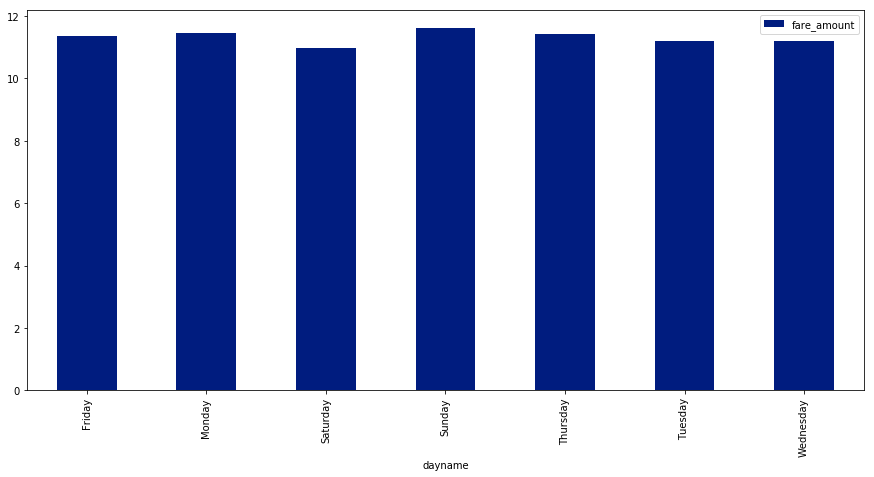

In [13]:
plt.style.use('seaborn-dark-palette')
df1 = dayfare.groupby(['dayname']).mean()
df1.plot.bar(legend=True, figsize = (15,7))    
plt.show()

In [14]:
df1.head(7)

,fare_amount
dayname,
Friday,11.375155
Monday,11.458996
Saturday,10.959638
Sunday,11.619501
Thursday,11.414325
Tuesday,11.205847
Wednesday,11.208045


In [15]:
useful_columns = ['fare_amount', 'hour'] #list the columns I need
hours = taxi_new[useful_columns]

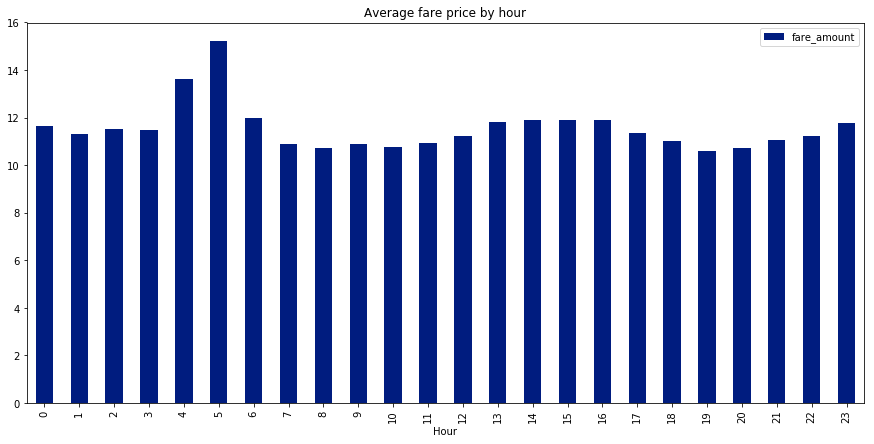

In [16]:
df1 = hours.groupby(['hour']).mean()
df1.plot.bar(legend=True, figsize = (15,7))
plt.xlabel('Hour')
plt.title('Average fare price by hour')
plt.show()

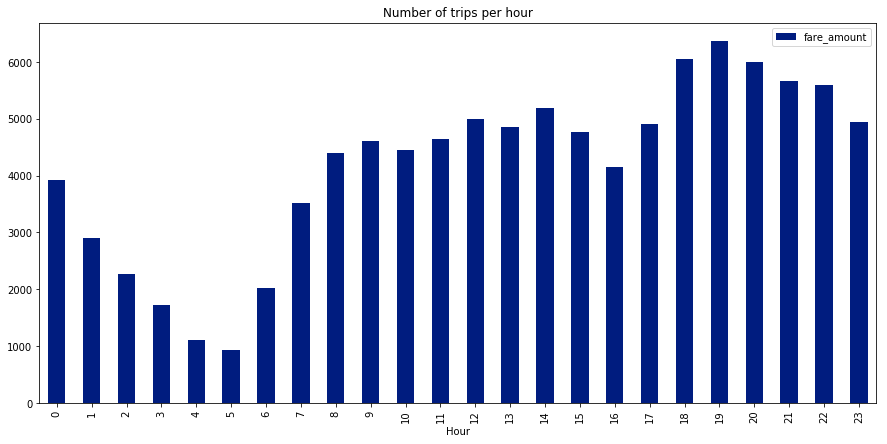

In [17]:
df2 = hours.groupby(['hour']).count()
df2.plot.bar(figsize = (15,7))
plt.xlabel('Hour')
plt.title('Number of trips per hour')
plt.show()

In [18]:
df2

,fare_amount
hour,
0,3926
1,2909
2,2274
3,1723
4,1113
5,932
6,2029
7,3526
8,4401


### Location

In [19]:
import folium
from folium import plugins
import json

In [20]:
pickup_locations = taxi_new[['pickup_longitude', 'pickup_latitude']]
dropoff_locations = taxi_new[['dropoff_longitude', 'dropoff_latitude']]
p_locationlist = pickup_locations.values.tolist()
d_locationlist = dropoff_locations.values.tolist()

In [21]:
dropoff_locations.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 311497 to 30749394
Data columns (total 2 columns):
dropoff_longitude    99999 non-null float64
dropoff_latitude     99999 non-null float64
dtypes: float64(2)
memory usage: 4.8 MB


In [28]:
m = folium.Map(location=[40.7128, -74.0060], height=1000, zoom_start=13, tiles='OpenStreetMap')
m.add_child(plugins.HeatMap(zip(taxi_new['pickup_latitude'],taxi_new['pickup_longitude'],taxi_new['fare_amount']), radius = 8)) 
m.save('pickupmap.html')

### Passenger Count

In [23]:
from matplotlib.pyplot import figure

In [30]:
useful_columns = ['fare_amount', 'passenger_count'] #list the columns I need
passenger = taxi_new[useful_columns]
passenger = passenger[passenger['passenger_count']<10]
passenger = passenger[passenger['passenger_count']>0]

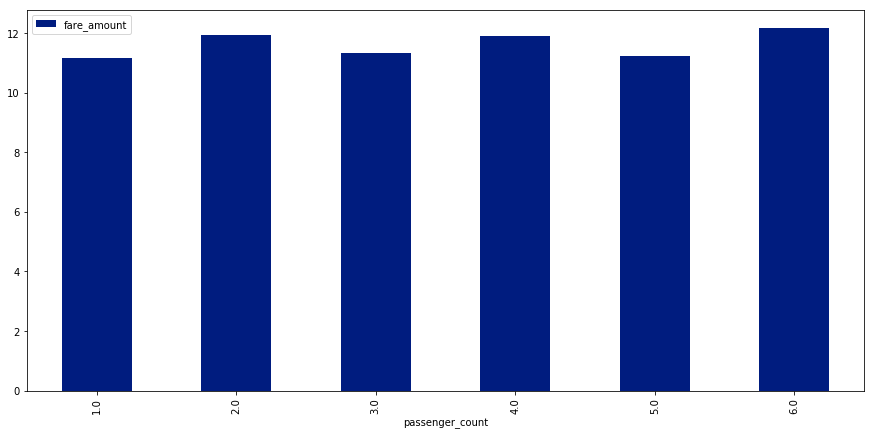

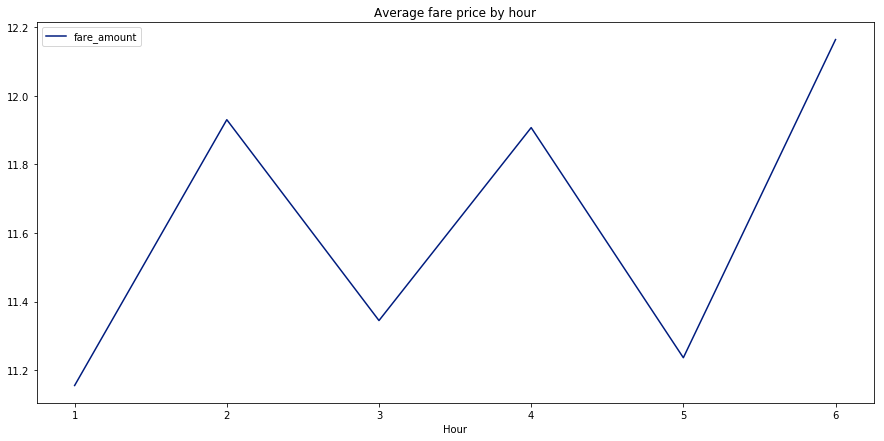

In [31]:
df1 = passenger.groupby(['passenger_count']).mean()
df1.plot.bar(legend=True, figsize = (15,7))
df1.plot.line(legend=True, figsize = (15,7))
plt.xlabel('Hour')
plt.title('Average fare price by hour')
plt.show()

In [32]:
df1

,fare_amount
passenger_count,
1.0,11.155331
2.0,11.929920
3.0,11.344645
4.0,11.906842
5.0,11.236294
6.0,12.163396


Text(0.5, 1.0, 'Number of trips by passengers')

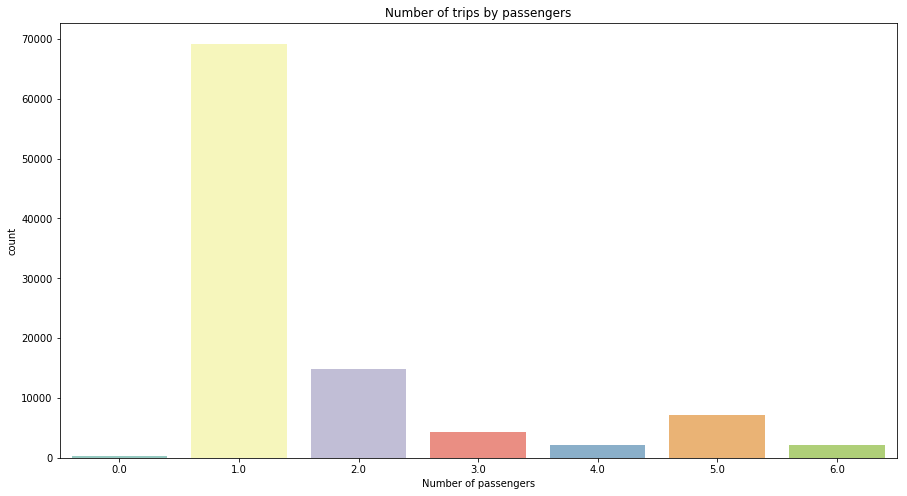

In [26]:
plt.figure(figsize=(15,8))
sns.countplot(x='passenger_count',data=passenger, palette="Set3")
plt.xlabel('Number of passengers')
plt.title('Number of trips by passengers')

In [27]:
passenger

,fare_amount,passenger_count
311497,16.00,5.0
28743711,4.50,1.0
42622178,19.00,5.0
14444931,8.50,5.0
24320687,22.00,1.0
21449880,9.10,1.0
41232863,19.50,1.0
20214126,18.50,1.0
10099312,9.50,1.0
6314616,49.80,2.0
